In [1]:
import pandas as pd,numpy as np, gc

In [2]:
sample = pd.read_csv('sample_submission.csv')
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
orig = pd.read_csv('diabetes_dataset.csv')

train.shape, test.shape, sample.shape, orig.shape

((700000, 26), (300000, 25), (300000, 2), (100000, 31))

In [3]:
TARGET = 'diagnosed_diabetes'
BASE = [col for col in train.columns if col not in [TARGET]]
CATS = train.select_dtypes('object').columns.to_list()
NUMS = [col for col in BASE if col not in CATS]
print(f'{len(BASE)} Base Features:{BASE}')

25 Base Features:['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']


In [4]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

In [4]:
ORIG = []

# Only iterate over columns that exist in `orig` to avoid KeyErrors (e.g., engineered cols)
common_cols = [col for col in BASE if col in orig.columns]

for col in common_cols:
    # MEAN (use reset_index to produce a DataFrame before merging)
    mean_map = orig.groupby(col)[TARGET].mean().reset_index(name=f"orig_mean_{col}")
    new_mean_col_name = f"orig_mean_{col}"

    train = train.merge(mean_map, on=col, how='left')
    test = test.merge(mean_map, on=col, how='left')
    ORIG.append(new_mean_col_name)

    # COUNT
    new_count_col_name = f"orig_count_{col}"
    count_map = orig.groupby(col).size().reset_index(name=new_count_col_name)

    train = train.merge(count_map, on=col, how='left')
    test = test.merge(count_map, on=col, how='left')
    ORIG.append(new_count_col_name)

for col in ORIG:
    if 'mean' in col:
        train[col] = train[col].fillna(orig[TARGET].mean())
        test[col] = test[col].fillna(orig[TARGET].mean())
    else:
        train[col] = train[col].fillna(0)
        test[col] = test[col].fillna(0)
    

In [5]:
FEATURES = BASE + ORIG
print(len(FEATURES), 'Features.')
X = train[FEATURES]
y = train[TARGET]

73 Features.


In [10]:
X["bmi_bin"] = pd.cut(
    train["bmi"],
    bins=[0, 25, 30, 100],
    labels=["normal", "overweight", "obese"]
)
test["bmi_bin"] = pd.cut(
    test["bmi"],
    bins=[0, 25, 30, 100],
    labels=["normal", "overweight", "obese"]
)
CATS.append("bmi_bin")
FEATURES.append("bmi_bin")

X["age_bin"] = pd.cut(
    X["age"],
    bins=[0, 40, 50, 60, 120],
    labels=["<40", "40-50", "50-60", "60+"]
)
test["age_bin"] = pd.cut(
    test["age"],
    bins=[0, 40, 50, 60, 120],
    labels=["<40", "40-50", "50-60", "60+"]
)
CATS.append("age_bin")
FEATURES.append("age_bin")

X["activity_clipped"] = X["physical_activity_minutes_per_week"].clip(0, 300)
X["activity_bin"] = pd.cut(
    X["activity_clipped"],
    bins=[0, 60, 150, 1000],
    labels=["low", "moderate", "high"]
)
test["activity_clipped"] = test["physical_activity_minutes_per_week"].clip(0, 300)
test["activity_bin"] = pd.cut(
    test["activity_clipped"],
    bins=[0, 60, 150, 1000],
    labels=["low", "moderate", "high"]
)
X.drop(columns=['activity_clipped'], inplace=True)
CATS.append("activity_bin")
FEATURES.append("activity_bin")

# Create factorized pairwise interaction features (numeric codes) using combined factorize
interaction_cols = []
for col in ["bmi_bin", "age_bin", "activity_bin"]:
    name = f'{col}_x_fh'
    # build combined string in train and test
    X[name] = X[col].astype(str) + '_' + X['family_history_diabetes'].astype(str)
    test[name] = test[col].astype(str) + '_' + test['family_history_diabetes'].astype(str)
    # factorize across the concatenated series so train/test share codes
    combined = pd.concat([X[name], test[name]], ignore_index=True)
    codes, uniques = pd.factorize(combined)
    # Drop feature if cardinality is too high (more than 50% unique values)
    if pd.Series(codes).nunique() > len(codes) // 2:
        X = X.drop(columns=[name])
        test = test.drop(columns=[name])
        print(f'Dropped {name} due to high cardinality')
        continue
    # split codes back into train/test and store as numeric factor columns
    X[f'{name}_fact'] = codes[:len(X)]
    test[f'{name}_fact'] = codes[len(X):len(X) + len(test)]
    interaction_cols.append(f'{name}_fact')
    # remove the temporary string columns
    X.drop(columns=[name], inplace=True)
    test.drop(columns=[name], inplace=True)
# Add factorized interaction columns to NUMS so they are processed by the numeric pipeline
NUMS.extend(interaction_cols)
print('Added interaction numeric cols to NUMS:', interaction_cols)
FEATURES = FEATURES + interaction_cols
print(f'Total Features after interaction: {len(FEATURES)}')

Added interaction numeric cols to NUMS: ['bmi_bin_x_fh_fact', 'age_bin_x_fh_fact', 'activity_bin_x_fh_fact']
Total Features after interaction: 85


In [11]:
# -----------------------------------------------------
# 0. Helper: Memory Reducer
# -----------------------------------------------------
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and col_type.name != 'category':
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[
                        col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    return df

X = reduce_mem_usage(X)
test = reduce_mem_usage(test)
gc.collect()

0

# XGBOOST

In [12]:
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
from sklearn.metrics import roc_auc_score   
# -----------------------------------------------------
# 4.3 Training Loop (XGBoost)
# -----------------------------------------------------

# Initialize arrays
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))

# Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


TE_COLS = interaction_cols
print(f"Target Encoding applied to {len(TE_COLS)} features.")

# XGBoost Parameters
xgb_params = {
    'n_estimators': 20000,
    'learning_rate': 0.01,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'auc',
    'device': 'cuda',           # GPU (optional)
    'enable_categorical': True,   # Native Categorical Support
    'early_stopping_rounds': 200,
}

print(f"Starting Training...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    
    # 1. Split Data
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]
    X_test_fold = test[FEATURES].copy() 
    
    # -----------------------------------------------------
    # A. Target Encoding (Augment Numerical Features)
    # -----------------------------------------------------
    if len(TE_COLS) > 0:
        TE = TargetEncoder(cols_to_encode=TE_COLS, cv=5, smooth='auto', aggs=['mean', 'count'], drop_original=False)
        X_train = TE.fit_transform(X_train, y_train)
        X_val = TE.transform(X_val)
        X_test_fold = TE.transform(X_test_fold)

    # -----------------------------------------------------
    # B. Factorize CATS & Prepare for Native Support
    # -----------------------------------------------------
    for c in CATS:
        # 1. Factorize (Returns NumPy Array)
        combined = pd.concat([X_train[c], X_val[c], X_test_fold[c]])
        combined_encoded, _ = combined.factorize()
        
        # 2. Assign back to DataFrame to convert to Series
        X_train[c] = combined_encoded[:len(X_train)]
        X_val[c] = combined_encoded[len(X_train):len(X_train)+len(X_val)]
        X_test_fold[c] = combined_encoded[len(X_train)+len(X_val):]

        # 3. Cast to Category
        X_train[c] = X_train[c].astype('category')
        X_val[c] = X_val[c].astype('category')
        X_test_fold[c] = X_test_fold[c].astype('category')

    # -----------------------------------------------------
    # C. Train Model (XGBClassifier)
    # -----------------------------------------------------
    model = xgb.XGBClassifier(**xgb_params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=500
    )

    # Predict
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    test_preds += model.predict_proba(X_test_fold)[:, 1] / kf.get_n_splits()
    
    fold_score = roc_auc_score(y_val, val_preds)
    print(f"Fold {fold+1} AUC: {fold_score:.5f}")

    if len(TE_COLS) > 0: del TE
    gc.collect()
print("-" * 30)
print(f"OOF AUC: {roc_auc_score(y, oof_preds):.5f}")

Target Encoding applied to 3 features.
Starting Training...


C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

[0]	validation_0-auc:0.69753
[500]	validation_0-auc:0.72366
[1000]	validation_0-auc:0.72658
[1500]	validation_0-auc:0.72808
[2000]	validation_0-auc:0.72903
[2500]	validation_0-auc:0.72962
[3000]	validation_0-auc:0.73008
[3500]	validation_0-auc:0.73042
[4000]	validation_0-auc:0.73067
[4500]	validation_0-auc:0.73088
[5000]	validation_0-auc:0.73100
[5500]	validation_0-auc:0.73111
[6000]	validation_0-auc:0.73121
[6500]	validation_0-auc:0.73130
[7000]	validation_0-auc:0.73135
[7500]	validation_0-auc:0.73139
[8000]	validation_0-auc:0.73145
[8500]	validation_0-auc:0.73148
[8994]	validation_0-auc:0.73148


c:\Users\as\miniconda3\envs\general\Lib\site-packages\xgboost\core.py:774: UserWarning: [19:18:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold 1 AUC: 0.73149


...

[0]	validation_0-auc:0.69663
[500]	validation_0-auc:0.72218
[1000]	validation_0-auc:0.72507
[1500]	validation_0-auc:0.72674
[2000]	validation_0-auc:0.72780
[2500]	validation_0-auc:0.72849
[3000]	validation_0-auc:0.72899
[3500]	validation_0-auc:0.72941
[4000]	validation_0-auc:0.72972
[4500]	validation_0-auc:0.72995
[5000]	validation_0-auc:0.73013
[5500]	validation_0-auc:0.73027
[6000]	validation_0-auc:0.73040
[6500]	validation_0-auc:0.73052
[7000]	validation_0-auc:0.73058
[7500]	validation_0-auc:0.73066
[8000]	validation_0-auc:0.73073
[8500]	validation_0-auc:0.73077
[9000]	validation_0-auc:0.73081
[9500]	validation_0-auc:0.73085
[9677]	validation_0-auc:0.73083
Fold 3 AUC: 0.73085


C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

[0]	validation_0-auc:0.69478
[500]	validation_0-auc:0.72246
[1000]	validation_0-auc:0.72569
[1500]	validation_0-auc:0.72742
[2000]	validation_0-auc:0.72844
[2500]	validation_0-auc:0.72914
[3000]	validation_0-auc:0.72961
[3500]	validation_0-auc:0.72996
[4000]	validation_0-auc:0.73028
[4500]	validation_0-auc:0.73050
[5000]	validation_0-auc:0.73067
[5500]	validation_0-auc:0.73082
[6000]	validation_0-auc:0.73096
[6500]	validation_0-auc:0.73104
[7000]	validation_0-auc:0.73109
[7500]	validation_0-auc:0.73113
[8000]	validation_0-auc:0.73120
[8500]	validation_0-auc:0.73123
[8955]	validation_0-auc:0.73124
Fold 4 AUC: 0.73125


C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

[0]	validation_0-auc:0.69550
[500]	validation_0-auc:0.72296
[1000]	validation_0-auc:0.72620
[1500]	validation_0-auc:0.72783
[2000]	validation_0-auc:0.72880
[2500]	validation_0-auc:0.72942
[3000]	validation_0-auc:0.72986
[3500]	validation_0-auc:0.73018
[4000]	validation_0-auc:0.73042
[4500]	validation_0-auc:0.73063
[5000]	validation_0-auc:0.73076
[5500]	validation_0-auc:0.73089
[6000]	validation_0-auc:0.73096
[6464]	validation_0-auc:0.73099
Fold 5 AUC: 0.73100
------------------------------
OOF AUC: 0.73093


C:\Users\as\AppData\Local\Temp\ipykernel_9680\626068710.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(40), x='Importance', y='Feature', palette='viridis')


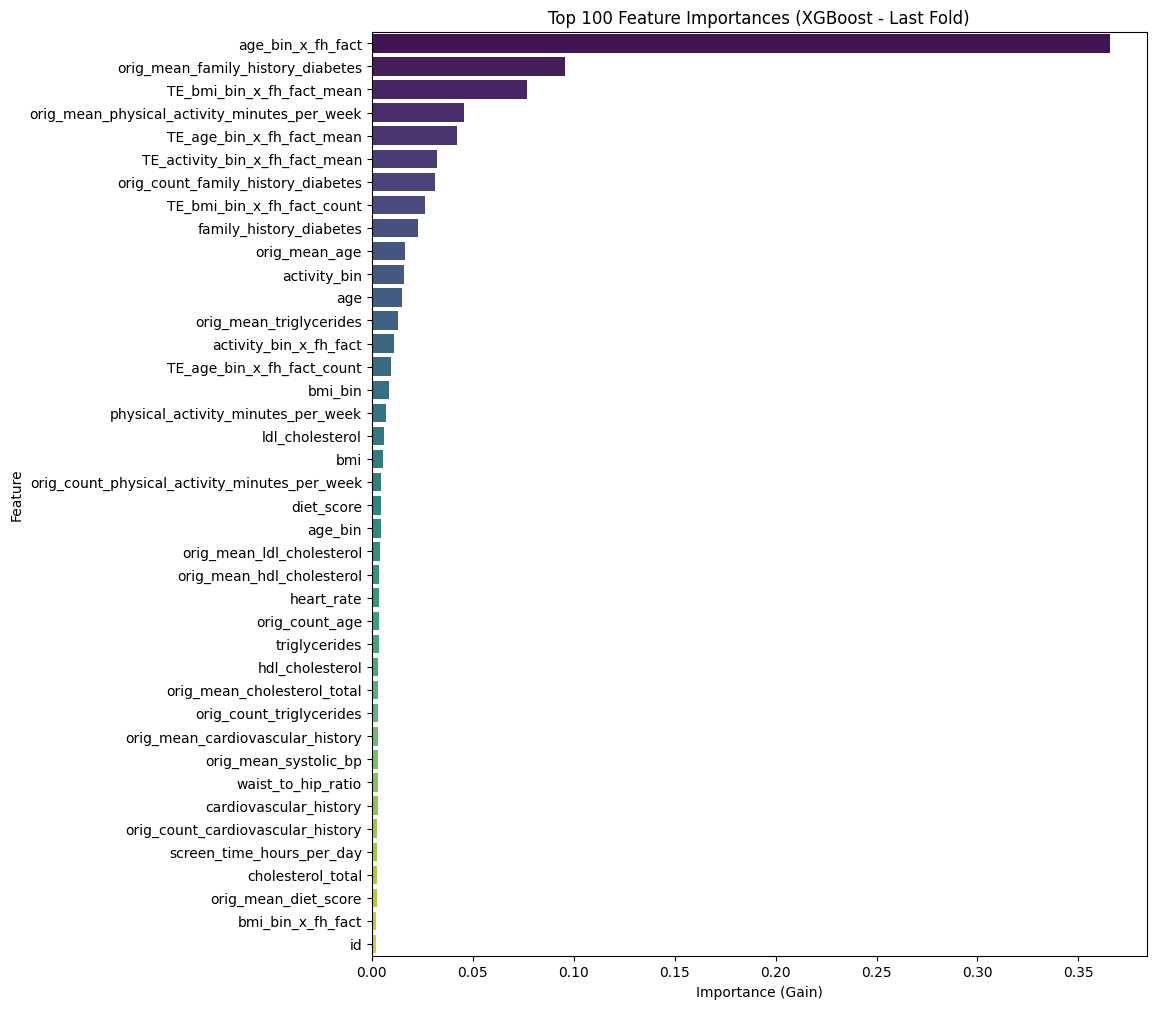

In [13]:
# Extract importances from the last trained model
# (Note: Ideally we average importances across all folds, but the last fold serves as a good proxy for a baseline)
import matplotlib.pyplot as plt
import seaborn as sns
imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(data=imp_df.head(40), x='Importance', y='Feature', palette='viridis')
plt.title('Top 100 Feature Importances (XGBoost - Last Fold)')
plt.xlabel('Importance (Gain)')
plt.ylabel('Feature')
plt.show()


Submission and OOF files saved successfully.
Submission Shape: (300000, 2)


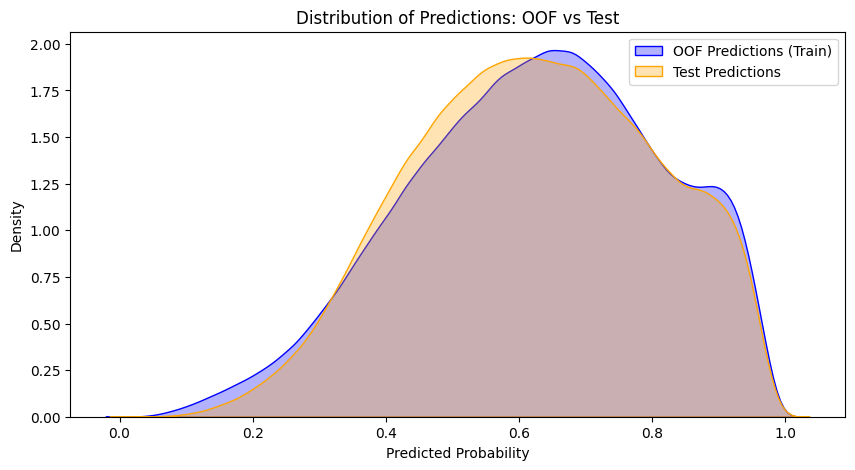

,id,diagnosed_diabetes
0,700000,0.454126
1,700001,0.678011
2,700002,0.784427
3,700003,0.416738
4,700004,0.910086


In [ ]:
# 1. Create Submission DataFrame
sub = pd.read_csv('sample_submission.csv')
sub[TARGET] = test_preds
sub.to_csv('submission_robust_te_withid.csv', index=False)

# 2. Save OOF Predictions (for Ensembling)
# OOF dataframe creating ensures we match the correct IDs
oof_df = pd.DataFrame()
oof_df['id'] = train['id']
oof_df[TARGET] = y
oof_df['pred'] = oof_preds
oof_df.to_csv('oof_predictions.csv', index=False)

print('Submission and OOF files saved successfully.')
print(f'Submission Shape: {sub.shape}')

# 3. Sanity Check: Distribution Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(oof_df['pred'], label='OOF Predictions (Train)', fill=True, color='blue', alpha=0.3)
sns.kdeplot(sub[TARGET], label='Test Predictions', fill=True, color='orange', alpha=0.3)
plt.title('Distribution of Predictions: OOF vs Test')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
plt.show()

sub.head()

# LGBM

In [18]:
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 10000,
    'learning_rate': 0.005,
    'num_leaves': 95,
    'max_depth': 8, 
    'min_child_samples': 25, 
    'subsample': 0.8,
    'colsample_bytree': 0.7, 
    'subsample_freq': 1,
    'min_gain_to_split': 0.02,
    'reg_alpha': 3,
    'reg_lambda': 1.2, 
    'scale_pos_weight': None, 
    'max_bin': 255,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'early_stopping_rounds': 100
}



Starting LightGBM Training...
Fold 1/5


C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

 Fold 1 AUC: 0.73128
Fold 2/5


C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

 Fold 2 AUC: 0.72996
Fold 3/5


...

C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

 Fold 4 AUC: 0.73140
Fold 5/5


C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_9680\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

 Fold 5 AUC: 0.73137
------------------------------
LGBM OOF AUC: 0.7309029846580247


C:\Users\as\AppData\Local\Temp\ipykernel_9680\4127139323.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi.head(40), x='importance', y='feature', palette='rocket')


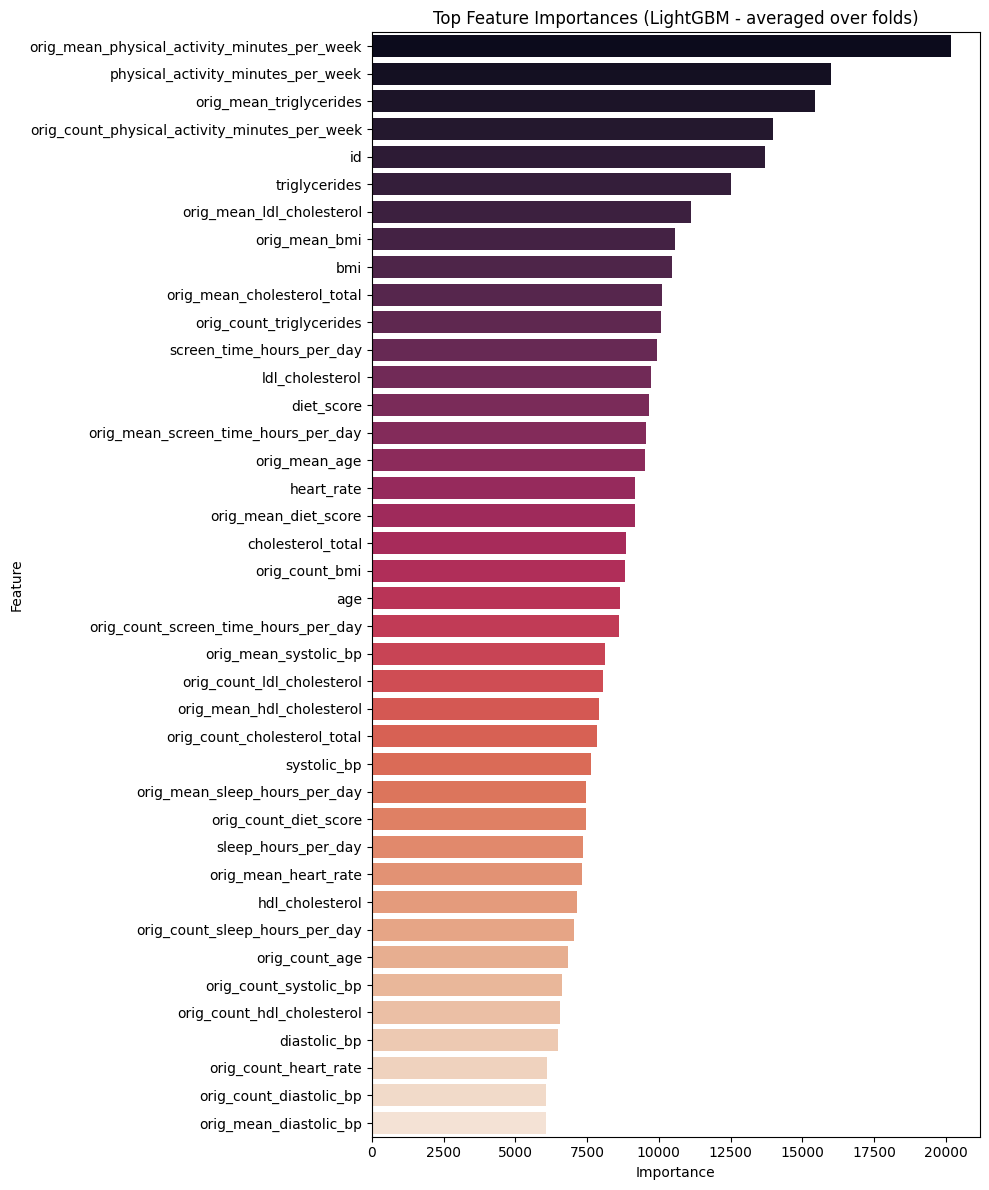

LGBM: submission, oof and importances saved.


In [19]:
# -----------------------------------------------------
# LGBM: Stratified K-Fold Training (restored)
# -----------------------------------------------------
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize
oof_preds_lgb = np.zeros(len(X))
test_preds_lgb = np.zeros(len(test))
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
feature_importance_df = pd.DataFrame()

print('Starting LightGBM Training...')

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f'Fold {fold+1}/{kf.get_n_splits()}')
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]
    X_test_fold = test[FEATURES].copy()

    # Target Encoding (if any) — same behaviour as XGB cell
    if len(TE_COLS) > 0:
        TE = TargetEncoder(cols_to_encode=TE_COLS, cv=5, smooth='auto', aggs=['mean','count'], drop_original=False)
        X_train = TE.fit_transform(X_train, y_train)
        X_val = TE.transform(X_val)
        X_test_fold = TE.transform(X_test_fold)

    # Factorize categorical columns and cast to category for native LGBM handling
    for c in CATS:
        combined = pd.concat([X_train[c], X_val[c], X_test_fold[c]])
        combined_encoded, _ = combined.factorize()
        X_train[c] = combined_encoded[:len(X_train)]
        X_val[c] = combined_encoded[len(X_train):len(X_train)+len(X_val)]
        X_test_fold[c] = combined_encoded[len(X_train)+len(X_val):]
        X_train[c] = X_train[c].astype('category')
        X_val[c] = X_val[c].astype('category')
        X_test_fold[c] = X_test_fold[c].astype('category')

    # Prepare model — pop fit-only args before init
    fit_params = dict(lgb_params) if isinstance(lgb_params, dict) else {}
    clf = lgb.LGBMClassifier(**fit_params)

    clf.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
    )

    # Predict
    val_pred = clf.predict_proba(X_val)[:, 1]
    oof_preds_lgb[val_idx] = val_pred
    fold_auc = roc_auc_score(y_val, val_pred)
    print(f' Fold {fold+1} AUC: {fold_auc:.5f}')

    test_preds_lgb += clf.predict_proba(X_test_fold)[:, 1] / kf.get_n_splits()

    # Feature importances (use the actual trained feature names)
    imp = pd.DataFrame({'feature': X_train.columns, 'importance': clf.feature_importances_})
    imp['fold'] = fold + 1
    feature_importance_df = pd.concat([feature_importance_df, imp], axis=0)

    # clean up
    if len(TE_COLS) > 0: del TE
    del clf
    gc.collect()

print('-'*30)
print('LGBM OOF AUC:', roc_auc_score(y, oof_preds_lgb))

# Aggregate importances
fi = feature_importance_df.groupby('feature')['importance'].mean().reset_index().sort_values('importance', ascending=False)

# Plot top features
plt.figure(figsize=(10, 12))
sns.barplot(data=fi.head(40), x='importance', y='feature', palette='rocket')
plt.title('Top Feature Importances (LightGBM - averaged over folds)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Save submission and OOF
sub_lgb = pd.read_csv('sample_submission.csv')
sub_lgb[TARGET] = test_preds_lgb
sub_lgb.to_csv('submission_lgbm.csv', index=False)

oof_df_lgb = pd.DataFrame({'id': train['id'], TARGET: y, 'pred': oof_preds_lgb})
oof_df_lgb.to_csv('oof_lgbm.csv', index=False)
fi.to_csv('feature_importances_lgbm.csv', index=False)
print('LGBM: submission, oof and importances saved.')

# CATBOOST


Starting CatBoost Training...
Fold 1/5


C:\Users\as\AppData\Local\Temp\ipykernel_21764\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_21764\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

0:	test: 0.6895002	best: 0.6895002 (0)	total: 416ms	remaining: 1h 9m 20s
500:	test: 0.7237790	best: 0.7237790 (500)	total: 2m 30s	remaining: 47m 28s
1000:	test: 0.7262578	best: 0.7262578 (1000)	total: 5m 3s	remaining: 45m 26s
1500:	test: 0.7278957	best: 0.7278957 (1500)	total: 7m 39s	remaining: 43m 22s
2000:	test: 0.7290312	best: 0.7290312 (2000)	total: 10m 16s	remaining: 41m 5s
2500:	test: 0.7295969	best: 0.7295969 (2500)	total: 12m 55s	remaining: 38m 44s
3000:	test: 0.7299379	best: 0.7299380 (2990)	total: 15m 35s	remaining: 36m 22s
3500:	test: 0.7301933	best: 0.7301955 (3492)	total: 18m 15s	remaining: 33m 54s
4000:	test: 0.7304173	best: 0.7304179 (3999)	total: 21m 1s	remaining: 31m 32s
4500:	test: 0.7305874	best: 0.7305876 (4498)	total: 25m 45s	remaining: 31m 28s
5000:	test: 0.7306987	best: 0.7307014 (4975)	total: 31m 54s	remaining: 31m 53s
5500:	test: 0.7307875	best: 0.7307875 (5500)	total: 38m 2s	remaining: 31m 6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0

C:\Users\as\AppData\Local\Temp\ipykernel_21764\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_21764\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

0:	test: 0.6862418	best: 0.6862418 (0)	total: 875ms	remaining: 2h 25m 51s
500:	test: 0.7217671	best: 0.7217671 (500)	total: 5m 54s	remaining: 1h 51m 59s
1000:	test: 0.7243454	best: 0.7243454 (1000)	total: 12m 2s	remaining: 1h 48m 18s
1500:	test: 0.7260251	best: 0.7260251 (1500)	total: 18m 1s	remaining: 1h 42m 3s
2000:	test: 0.7272035	best: 0.7272035 (2000)	total: 24m 2s	remaining: 1h 36m 4s
2500:	test: 0.7278588	best: 0.7278590 (2499)	total: 30m 3s	remaining: 1h 30m 7s
3000:	test: 0.7282892	best: 0.7282902 (2998)	total: 33m 43s	remaining: 1h 18m 38s
3500:	test: 0.7286024	best: 0.7286024 (3499)	total: 39m 29s	remaining: 1h 13m 18s
4000:	test: 0.7288102	best: 0.7288107 (3999)	total: 43m 47s	remaining: 1h 5m 39s
4500:	test: 0.7289755	best: 0.7289755 (4500)	total: 46m 26s	remaining: 56m 44s
5000:	test: 0.7291056	best: 0.7291144 (4973)	total: 49m 8s	remaining: 49m 7s
5500:	test: 0.7292114	best: 0.7292114 (5500)	total: 51m 52s	remaining: 42m 25s
6000:	test: 0.7293062	best: 0.7293062 (6000)	t

...

C:\Users\as\AppData\Local\Temp\ipykernel_21764\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_21764\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

0:	test: 0.6882017	best: 0.6882017 (0)	total: 327ms	remaining: 54m 31s
500:	test: 0.7226178	best: 0.7226178 (500)	total: 2m 31s	remaining: 47m 59s
1000:	test: 0.7253340	best: 0.7253340 (1000)	total: 5m 20s	remaining: 48m
1500:	test: 0.7270582	best: 0.7270582 (1500)	total: 8m	remaining: 45m 19s
2000:	test: 0.7283249	best: 0.7283249 (2000)	total: 10m 41s	remaining: 42m 43s
2500:	test: 0.7290178	best: 0.7290178 (2500)	total: 13m 22s	remaining: 40m 5s
3000:	test: 0.7295416	best: 0.7295429 (2996)	total: 16m 3s	remaining: 37m 26s
3500:	test: 0.7298760	best: 0.7298767 (3499)	total: 18m 44s	remaining: 34m 46s
4000:	test: 0.7301253	best: 0.7301253 (4000)	total: 21m 23s	remaining: 32m 4s
4500:	test: 0.7303126	best: 0.7303126 (4500)	total: 23m 58s	remaining: 29m 17s
5000:	test: 0.7304720	best: 0.7304720 (5000)	total: 26m 36s	remaining: 26m 36s
5500:	test: 0.7305704	best: 0.7305712 (5498)	total: 29m 20s	remaining: 24m
6000:	test: 0.7307002	best: 0.7307002 (6000)	total: 31m 59s	remaining: 21m 19s
6

C:\Users\as\AppData\Local\Temp\ipykernel_21764\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\as\AppData\Local\Temp\ipykernel_21764\2034908936.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

0:	test: 0.6888515	best: 0.6888515 (0)	total: 313ms	remaining: 52m 7s
500:	test: 0.7228930	best: 0.7228930 (500)	total: 2m 36s	remaining: 49m 29s
1000:	test: 0.7254971	best: 0.7254971 (1000)	total: 5m 16s	remaining: 47m 26s
1500:	test: 0.7271898	best: 0.7271898 (1500)	total: 7m 54s	remaining: 44m 48s
2000:	test: 0.7283810	best: 0.7283810 (2000)	total: 10m 32s	remaining: 42m 10s
2500:	test: 0.7290491	best: 0.7290491 (2500)	total: 13m 10s	remaining: 39m 29s
3000:	test: 0.7294545	best: 0.7294545 (3000)	total: 15m 49s	remaining: 36m 54s
3500:	test: 0.7297388	best: 0.7297402 (3496)	total: 18m 27s	remaining: 34m 15s
4000:	test: 0.7299369	best: 0.7299369 (4000)	total: 21m 3s	remaining: 31m 34s
4500:	test: 0.7301073	best: 0.7301076 (4499)	total: 23m 40s	remaining: 28m 55s
5000:	test: 0.7302259	best: 0.7302276 (4989)	total: 26m 17s	remaining: 26m 16s
5500:	test: 0.7303459	best: 0.7303459 (5500)	total: 28m 52s	remaining: 23m 36s
6000:	test: 0.7304268	best: 0.7304268 (6000)	total: 31m 29s	remaini

C:\Users\as\AppData\Local\Temp\ipykernel_21764\3102630298.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_cb.head(40), x='importance', y='feature', palette='magma')


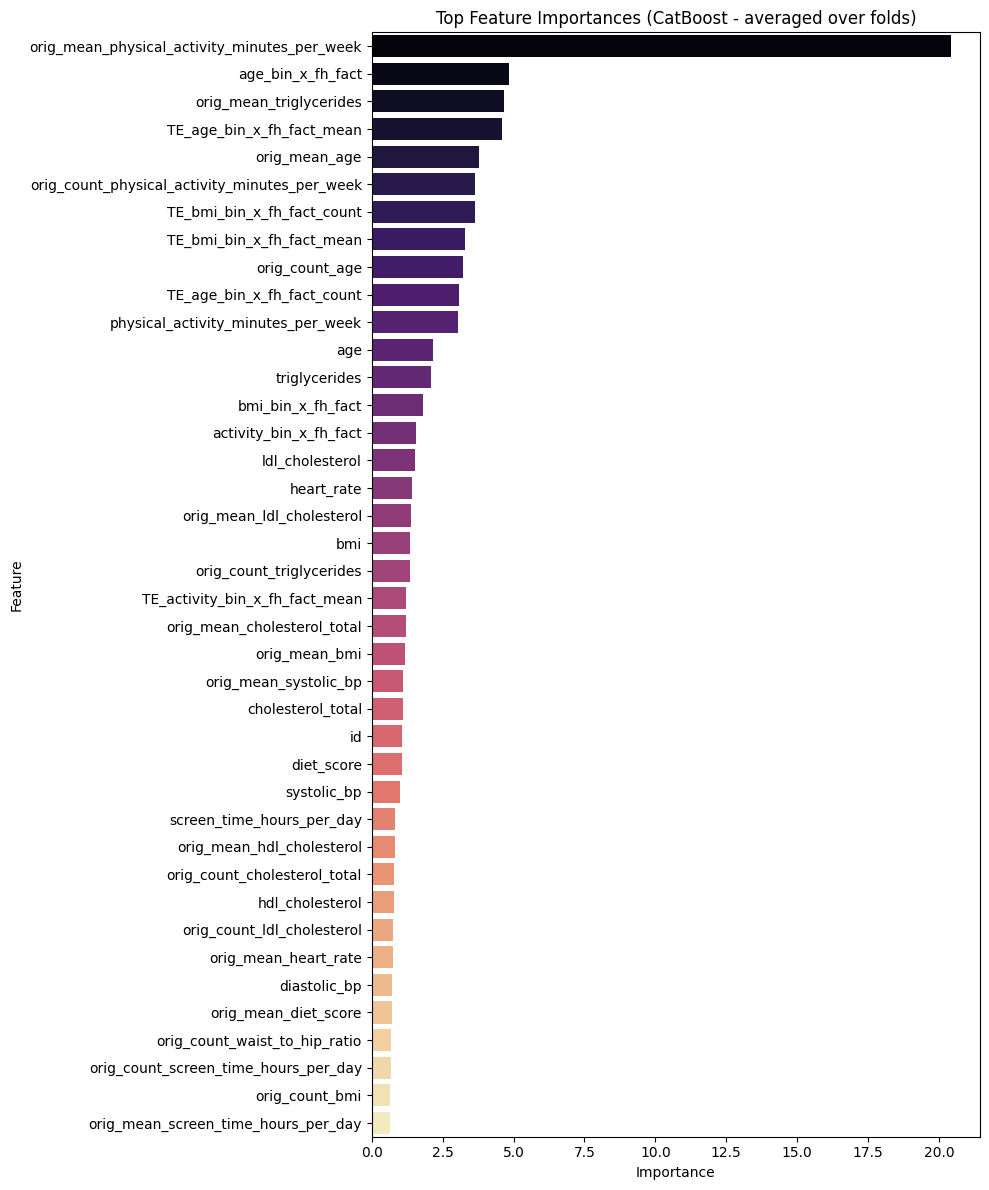

CatBoost: submission, oof and importances saved.


In [13]:
# -----------------------------------------------------
# CatBoost: Stratified K-Fold Training
# -----------------------------------------------------
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
TE_COLS = interaction_cols
# Initialize
oof_preds_cb = np.zeros(len(X))
test_preds_cb = np.zeros(len(test))
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
feature_importance_cb = pd.DataFrame()

print('Starting CatBoost Training...')

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f'Fold {fold+1}/{kf.get_n_splits()}')
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]
    X_test_fold = test[FEATURES].copy()

    # Target Encoding (if any)
    if len(TE_COLS) > 0:
        TE = TargetEncoder(cols_to_encode=TE_COLS, cv=5, smooth='auto', aggs=['mean','count'], drop_original=False)
        X_train = TE.fit_transform(X_train, y_train)
        X_val = TE.transform(X_val)
        X_test_fold = TE.transform(X_test_fold)

    # For CatBoost we can pass raw categorical feature names to Pool
    cat_feats = CATS if len(CATS) > 0 else None
    train_pool = Pool(X_train, y_train, cat_features=cat_feats)
    val_pool = Pool(X_val, y_val, cat_features=cat_feats)
    test_pool = Pool(X_test_fold, cat_features=cat_feats)

    cb = CatBoostClassifier(iterations=10000, learning_rate=0.01, depth=6, eval_metric='AUC', random_seed=42, thread_count=-1, verbose=500)
    cb.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

    # Predict
    val_pred = cb.predict_proba(X_val)[:, 1]
    oof_preds_cb[val_idx] = val_pred
    fold_auc = roc_auc_score(y_val, val_pred)
    print(f' Fold {fold+1} AUC: {fold_auc:.5f}')

    test_preds_cb += cb.predict_proba(X_test_fold)[:, 1] / kf.get_n_splits()

    # Feature importances
    imp_vals = cb.get_feature_importance(data=Pool(X_train, label=y_train, cat_features=cat_feats), type='FeatureImportance')
    imp = pd.DataFrame({'feature': X_train.columns, 'importance': imp_vals})
    imp['fold'] = fold + 1
    feature_importance_cb = pd.concat([feature_importance_cb, imp], axis=0)

    del cb, train_pool, val_pool, test_pool
    if len(TE_COLS) > 0: del TE
    gc.collect()

print('-'*30)
print('CatBoost OOF AUC:', roc_auc_score(y, oof_preds_cb))

# Aggregate importances
fi_cb = feature_importance_cb.groupby('feature')['importance'].mean().reset_index().sort_values('importance', ascending=False)

# Plot top features
plt.figure(figsize=(10, 12))
sns.barplot(data=fi_cb.head(40), x='importance', y='feature', palette='magma')
plt.title('Top Feature Importances (CatBoost - averaged over folds)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Save submission and OOF
sub_cb = pd.read_csv('sample_submission.csv')
sub_cb[TARGET] = test_preds_cb
sub_cb.to_csv('submission_catboost.csv', index=False)

oof_df_cb = pd.DataFrame({'id': train['id'], TARGET: y, 'pred': oof_preds_cb})
oof_df_cb.to_csv('oof_catboost.csv', index=False)
fi_cb.to_csv('feature_importances_catboost.csv', index=False)
print('CatBoost: submission, oof and importances saved.')

# RealMLP
